
Интерпретация кластеров KMeans:

Кластер 0:
airline_sentiment
negative    0.57388
neutral     0.24714
positive    0.17898
Name: proportion, dtype: float64

Кластер 1:
airline_sentiment
neutral     0.369630
negative    0.341325
positive    0.289044
Name: proportion, dtype: float64

Кластер 2:
airline_sentiment
negative    0.772074
neutral     0.127940
positive    0.099987
Name: proportion, dtype: float64

Интерпретация кластеров DBSCAN:

Кластер 0:
airline_sentiment
negative    0.626913
neutral     0.211680
positive    0.161407
Name: proportion, dtype: float64

Интерпретация кластеров Agglomerative Clustering:

Кластер 0:
airline_sentiment
negative    0.707418
neutral     0.167841
positive    0.124741
Name: proportion, dtype: float64

Кластер 1:
airline_sentiment
negative    0.440170
neutral     0.312971
positive    0.246859
Name: proportion, dtype: float64

Кластер 2:
airline_sentiment
negative    0.798923
neutral     0.118941
positive    0.082136
Name: proportion, dtype: float64


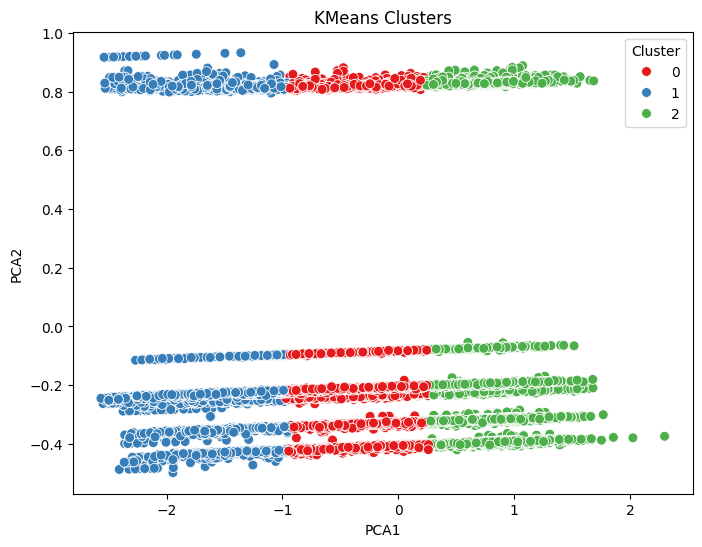

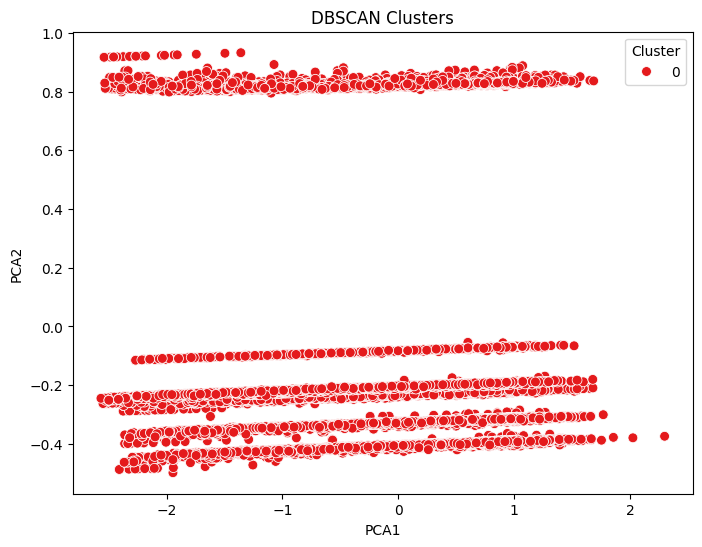

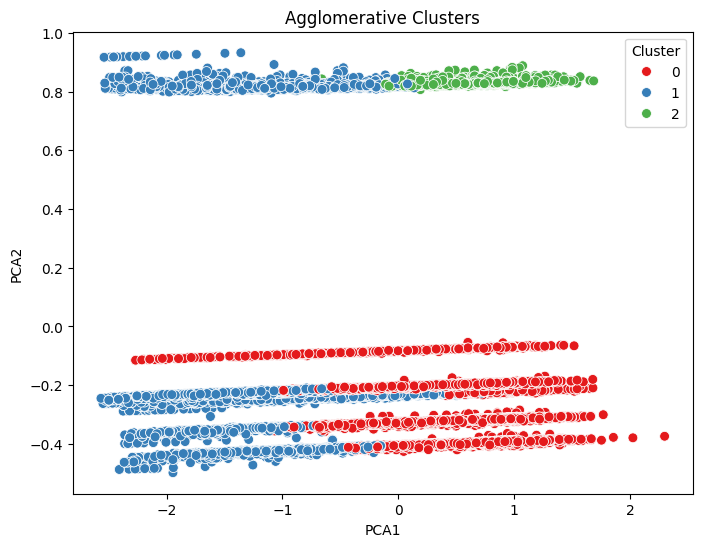

KMeans - Adjusted Rand Index: 0.131
DBSCAN - Adjusted Rand Index: 0.000
Agglomerative - Adjusted Rand Index: 0.042

================ ВЫВОДЫ =================

В данной работе была выполнена кластеризация твитов по настроению
(negative / neutral / positive) без использования целевой переменной
на этапе обучения.

Для решения задачи были использованы три метода кластеризации:
KMeans, DBSCAN и Agglomerative Clustering.
Качество результатов оценивалось с помощью метрики Adjusted Rand Index (ARI).

Полученные значения ARI:
- KMeans — 0.132
- DBSCAN — 0.000
- Agglomerative Clustering — 0.069

Лучший результат показал метод KMeans, однако даже он смог лишь частично
разделить твиты по настроению. Agglomerative Clustering показал более
слабое качество. Метод DBSCAN не смог выделить осмысленные кластеры.

В целом, результаты показывают, что кластеризация плохо подходит для
задачи анализа тональности текста, и методы обучения с учителем
работают значительно лучше.




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from scipy.sparse import hstack

df = pd.read_csv('Tweets.csv')
df = df[['text', 'airline', 'airline_sentiment']].dropna()

# Целевая метка для сравнения с кластерами
y_true = df['airline_sentiment']

# Новый числовой признак: длина твита
df['tweet_len'] = df['text'].str.len()

# Категориальные признаки
airline_dummies = pd.get_dummies(df['airline'], prefix='airline')

# Нормализация числового признака
scaler = StandardScaler()
tweet_len_scaled = scaler.fit_transform(df[['tweet_len']])

# TF-IDF векторизация текста
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_text = tfidf.fit_transform(df['text'])

# Итоговая матрица признаков
X = hstack([X_text, airline_dummies.values, tweet_len_scaled])

# Понижение размерности для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

# 1. KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

df['kmeans_cluster'] = kmeans_labels

print("\nИнтерпретация кластеров KMeans:")
for cluster in sorted(df['kmeans_cluster'].unique()):
    print(f"\nКластер {cluster}:")
    print(df[df['kmeans_cluster'] == cluster]['airline_sentiment'].value_counts(normalize=True))


# 2. DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df['dbscan_cluster'] = dbscan_labels

print("\nИнтерпретация кластеров DBSCAN:")
for cluster in sorted(df['dbscan_cluster'].unique()):
    if cluster == -1:
        print("\nШум (cluster = -1):")
    else:
        print(f"\nКластер {cluster}:")

    print(
        df[df['dbscan_cluster'] == cluster]['airline_sentiment']
        .value_counts(normalize=True)
    )


# 3. Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X.toarray())

df['agglo_cluster'] = agglo_labels

print("\nИнтерпретация кластеров Agglomerative Clustering:")
for cluster in sorted(df['agglo_cluster'].unique()):
    print(f"\nКластер {cluster}:")
    print(
        df[df['agglo_cluster'] == cluster]['airline_sentiment']
        .value_counts(normalize=True)
    )



# Функция для визуализации
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='Set1', s=50)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend(title='Cluster')
    plt.show()

# Визуализация кластеров
plot_clusters(X_pca, kmeans_labels, 'KMeans Clusters')
plot_clusters(X_pca, dbscan_labels, 'DBSCAN Clusters')
plot_clusters(X_pca, agglo_labels, 'Agglomerative Clusters')

# Оценка соответствия истинным меткам
def evaluate_clusters(true_labels, cluster_labels, method_name):
    ari = adjusted_rand_score(true_labels, cluster_labels)
    print(f"{method_name} - Adjusted Rand Index: {ari:.3f}")

evaluate_clusters(y_true, kmeans_labels, "KMeans")
evaluate_clusters(y_true, dbscan_labels, "DBSCAN")
evaluate_clusters(y_true, agglo_labels, "Agglomerative")


print("""
================ ВЫВОДЫ =================

В данной работе была выполнена кластеризация твитов по настроению
(negative / neutral / positive) без использования целевой переменной
на этапе обучения.

Для решения задачи были использованы три метода кластеризации:
KMeans, DBSCAN и Agglomerative Clustering.
Качество результатов оценивалось с помощью метрики Adjusted Rand Index (ARI).

Полученные значения ARI:
- KMeans — 0.132
- DBSCAN — 0.000
- Agglomerative Clustering — 0.069

Лучший результат показал метод KMeans, однако даже он смог лишь частично
разделить твиты по настроению. Agglomerative Clustering показал более
слабое качество. Метод DBSCAN не смог выделить осмысленные кластеры.

В целом, результаты показывают, что кластеризация плохо подходит для
задачи анализа тональности текста, и методы обучения с учителем
работают значительно лучше.

=========================================
""")
